# Test the betting strategies

### First we generate the data

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# import your class
# from your_module import ExponentialBet


# ----------------------------
# 1. DATA GENERATION
# ----------------------------

def generate_data(n=5000, d=5, rho=0.6, beta_strength=2.0, noise=1.0, seed=0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta = np.zeros(d)
    beta[j] = beta_strength

    gamma = np.ones(d)
    gamma[j] = 0.0

    eps = noise * np.random.randn(n)

    Y = X @ beta + X @ gamma + eps

    return X, Y, Sigma, j


# ----------------------------
# 2. EXACT CONDITIONAL SAMPLER
# ----------------------------

def sample_X_tilde(X_minus_j, j, Sigma, K=50):
    idx = np.arange(Sigma.shape[0]) != j

    Sigma11 = Sigma[j, j]
    Sigma12 = Sigma[j, idx]
    Sigma22 = Sigma[np.ix_(idx, idx)]

    Sigma22_inv = np.linalg.inv(Sigma22)

    mu = X_minus_j @ (Sigma12 @ Sigma22_inv).T
    var = Sigma11 - Sigma12 @ Sigma22_inv @ Sigma12.T

    noise = np.random.randn(len(X_minus_j), K) * np.sqrt(var)

    return mu[:, None] + noise


# ----------------------------
# 3. SETUP DATA
# ----------------------------

X, Y, Sigma, j = generate_data(beta_strength=0.8)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.5, random_state=0
)


# ----------------------------
# 4. TRAIN LINEAR MODEL
# ----------------------------

model = LinearRegression()
model.fit(X_train, y_train)




LinearRegression()

In [2]:
from Sampler import GaussianSampler, DefaultSampler, RegressorSampler
samp_G = GaussianSampler(j=0)
samp_G.fit(X_train)
X_tilde_G = samp_G.sample(X_test)

samp_R = RegressorSampler(j=0)
samp_R.fit(X_train)
X_tilde_R = samp_R.sample(X_test)

samp_D = DefaultSampler(j=0)
samp_D.fit(X_train)
X_tilde_D = samp_D.sample(X_test)

In [3]:
X_tilde_D.shape

(2500,)

(array([  3.,  17.,  80., 282., 567., 731., 525., 228.,  58.,   9.]),
 array([-3.97997882, -3.23634582, -2.49271281, -1.7490798 , -1.0054468 ,
        -0.26181379,  0.48181922,  1.22545222,  1.96908523,  2.71271824,
         3.45635124]),
 <BarContainer object of 10 artists>)

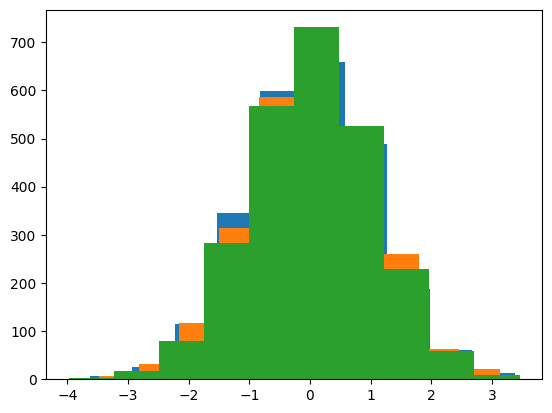

In [4]:
import matplotlib.pyplot as plt
plt.hist(X_tilde_G)
plt.hist(X_tilde_R)
plt.hist(X_tilde_D)



### Exponential strategy

Check under the alternative and then under the null

Final wealth vector: [1.78429300e+001 1.59224199e+068 6.33857454e+107 2.94386838e+125]
Mean wealth: [5.74912511e+000 6.04981996e+065 1.68213393e+105 7.05774800e+122]


(array([331., 112.,  30.,  14.,   3.,   2.,   2.,   1.,   2.,   2.]),
 array([ 0.03692707,  2.38498773,  4.73304838,  7.08110903,  9.42916969,
        11.77723034, 14.12529099, 16.47335164, 18.8214123 , 21.16947295,
        23.5175336 ]),
 <BarContainer object of 10 artists>)

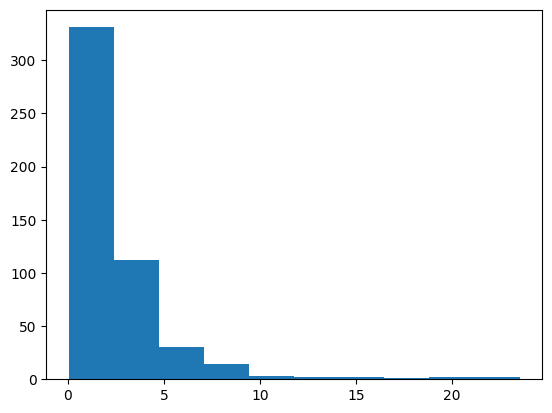

In [5]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from ExponentialBet import ExponentialBet  # adjust import
from utils import prepare_exponential_parameters

etas = prepare_exponential_parameters(0.01, 2, 4)
strategy = ExponentialBet(
    parameters=etas,
    exact=True
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_exp = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_exp = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_exp.append(e_val_exp)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_exp)

### Coin-betting



Final wealth vector: [1.61113079e+01 1.23117569e+01 7.58034496e+00 4.93692411e+00
 3.58213420e+00 2.84562313e+00 2.40970455e+00 2.13064073e+00
 1.94036246e+00 1.80346823e+00 6.50565652e+13 3.49117519e+12
 1.56253006e+10 1.21645120e+08 3.10996112e+06 2.19806804e+05
 3.20643678e+04 7.66171340e+03 2.57041862e+03 1.09118953e+03
 2.06403569e+25 1.26173363e+23 7.98086462e+18 1.19432855e+15
 1.45615679e+12 1.10524553e+10 3.12781765e+08 2.18258719e+07
 2.84221468e+06 5.71646189e+05 7.22874584e+35 7.55719237e+32
 1.18792415e+27 5.14065945e+21 3.89059397e+17 3.74413487e+14
 2.28604267e+12 4.99709155e+10 2.64959879e+09 2.61160493e+08
 3.61167006e+45 9.19553026e+41 5.86661720e+34 1.04934168e+28
 6.22102121e+22 8.80198097e+18 1.27602208e+16 9.31430675e+13
 2.10129963e+12 1.04732754e+11 3.11661291e+54 2.66106911e+50
 1.06686957e+42 1.08424403e+34 6.19926166e+27 1.47337562e+23
 5.53222124e+19 1.42980335e+17 1.42931339e+15 3.70895863e+13
 5.31861251e+62 2.06317246e+58 7.76346958e+48 5.98650130e+39
 3.

(array([  7.,  11.,  18.,  12.,  33.,  33.,  50.,  63.,  83., 189.]),
 array([0.2 , 0.38, 0.56, 0.74, 0.92, 1.1 , 1.28, 1.46, 1.64, 1.82, 2.  ]),
 <BarContainer object of 10 artists>)

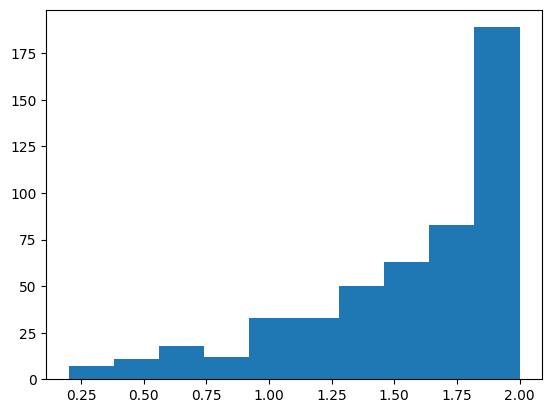

In [6]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_cb = []
for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_cb = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_cb.append(e_val_cb)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_cb)

In [7]:
wealth_path.shape

(499, 100)

In [8]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    e_val_path.append(e_val)
    
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.54440389e+01 1.20293486e+01 7.47554698e+00 4.88854122e+00
 3.55708337e+00 2.82835750e+00 2.39836221e+00 2.12320243e+00
 1.93465081e+00 1.79868591e+00 3.98728805e+13 2.67535371e+12
 1.32544147e+10 1.08028217e+08 2.85623301e+06 2.04277989e+05
 3.02878225e+04 7.34258277e+03 2.47982463e+03 1.05656000e+03
 8.29967702e+24 7.73214867e+22 5.85142085e+18 9.50946017e+14
 1.23533255e+12 9.60132207e+09 2.80241735e+08 2.00971885e+07
 2.65102593e+06 5.37021588e+05 1.93986509e+35 3.76188108e+32
 7.56534013e+26 3.67106489e+21 3.04610632e+17 3.03978355e+14
 1.94195050e+12 4.41765984e+10 2.38767565e+09 2.37905744e+08
 6.53010004e+44 3.76482493e+41 3.26105246e+34 6.72562640e+27
 4.49220457e+22 6.67810349e+18 1.02739722e+16 7.90066952e+13
 1.82837287e+12 9.24715733e+10 3.80450882e+53 9.04683315e+49
 5.20009099e+41 6.24228913e+33 4.12637786e+27 1.04459411e+23
 4.22088863e+19 1.16305391e+17 1.20023489e+15 3.17269633e+13
 4.35278811e+61 5.86215146e+57 3.33235116e+48 3.09839977e+39
 2.

In [9]:
strategy.e_value(model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j)

np.float64(1.92)

(array([  4.,  11.,  22.,  12.,  28.,  36.,  44.,  66.,  92., 184.]),
 array([0.12 , 0.308, 0.496, 0.684, 0.872, 1.06 , 1.248, 1.436, 1.624,
        1.812, 2.   ]),
 <BarContainer object of 10 artists>)

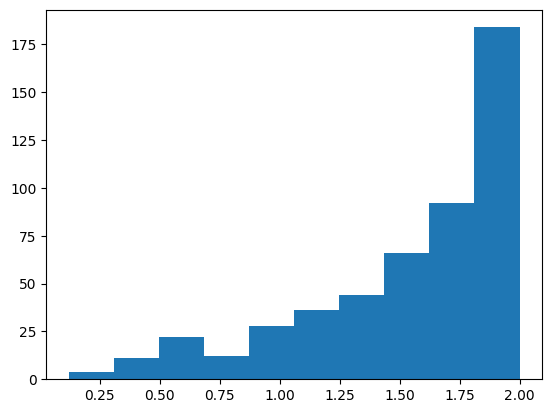

In [10]:
plt.hist(e_val_path)

### Test sign


In [11]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.56259397e+01 5.49834923e+27 4.06486521e+49 6.16156042e+67
 3.54374971e+82]
Mean wealth: [5.22724409e+00 7.35515317e+25 2.95209634e+47 3.26886631e+65
 1.55520644e+80]


(array([  4.,  11.,  14.,  21.,  25.,  36.,  46.,  58., 101., 183.]),
 array([0.5556 , 0.65054, 0.74548, 0.84042, 0.93536, 1.0303 , 1.12524,
        1.22018, 1.31512, 1.41006, 1.505  ]),
 <BarContainer object of 10 artists>)

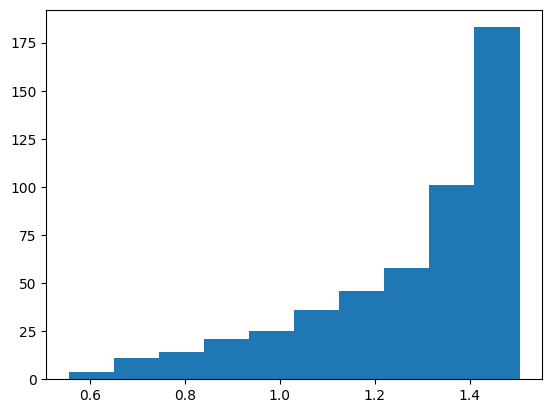

In [12]:
plt.hist(e_val_path_sign)

Final wealth vector: [1.52142254e+01 2.91321375e+27 1.25674731e+49 1.14167556e+67
 3.25097438e+81]
Mean wealth: [5.15604348e+00 3.84740000e+25 9.18128237e+46 6.13907238e+64
 1.44769468e+79]


(array([  3.,   9.,  14.,  20.,  24.,  44.,  43.,  70.,  87., 185.]),
 array([0.08 , 0.272, 0.464, 0.656, 0.848, 1.04 , 1.232, 1.424, 1.616,
        1.808, 2.   ]),
 <BarContainer object of 10 artists>)

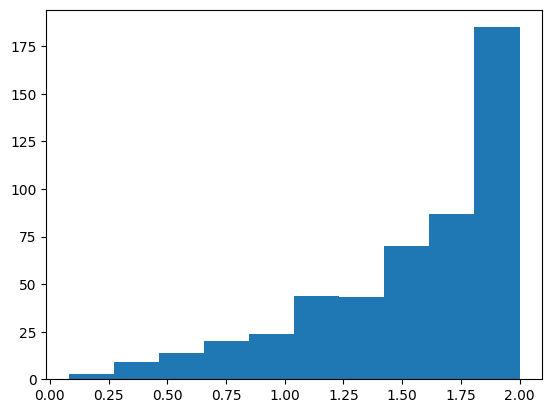

In [13]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)

### Tanh

Final wealth vector: [1.60408472e+01 1.04365335e+28 1.32076938e+50 2.97942237e+68
 1.50420629e+83]
Mean wealth: [5.28547175e+00 1.34822622e+26 9.35380278e+47 1.54859894e+66
 6.47484265e+80]


(array([  3.,   9.,  14.,  20.,  24.,  44.,  43.,  70.,  87., 185.]),
 array([0.08 , 0.272, 0.464, 0.656, 0.848, 1.04 , 1.232, 1.424, 1.616,
        1.808, 2.   ]),
 <BarContainer object of 10 artists>)

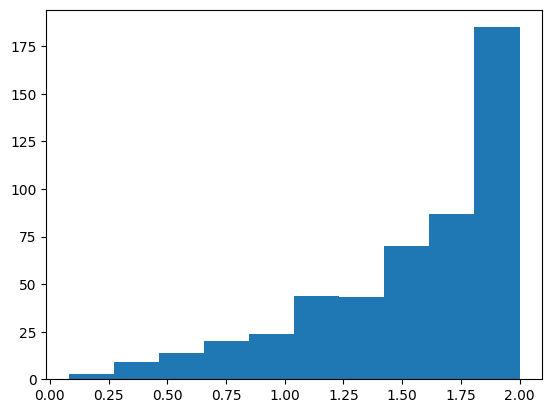

In [14]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_tanh, update_g_func_static

params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_tanh = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_tanh = strategy_tanh.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_tanh.update()
    e_val_path_tanh.append(e_val_tanh)
    wealth_path.append(strategy_tanh.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)